In [2]:
# [Cell 1] 라이브러리 임포트 및 데이터 로드
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 경고 메시지 무시 (깔끔한 출력을 위해)
import warnings
warnings.filterwarnings('ignore')

# 데이터 로드
df = pd.read_csv('Train.csv')

print(f"전체 데이터 개수: {len(df)}")
display(df.head())

전체 데이터 개수: 43398


,id,title,text,label
0,1,To offer down resource great point.,probably guess western behind likely next inve...,0.0
1,2,Himself church myself carry.,them identify forward present success risk sev...,0.0
2,3,You unit its should.,phone which item yard Republican safe where po...,0.0
3,4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,0.0
4,5,Center measure difference dark.,ready movement bed increase during or history ...,0.0


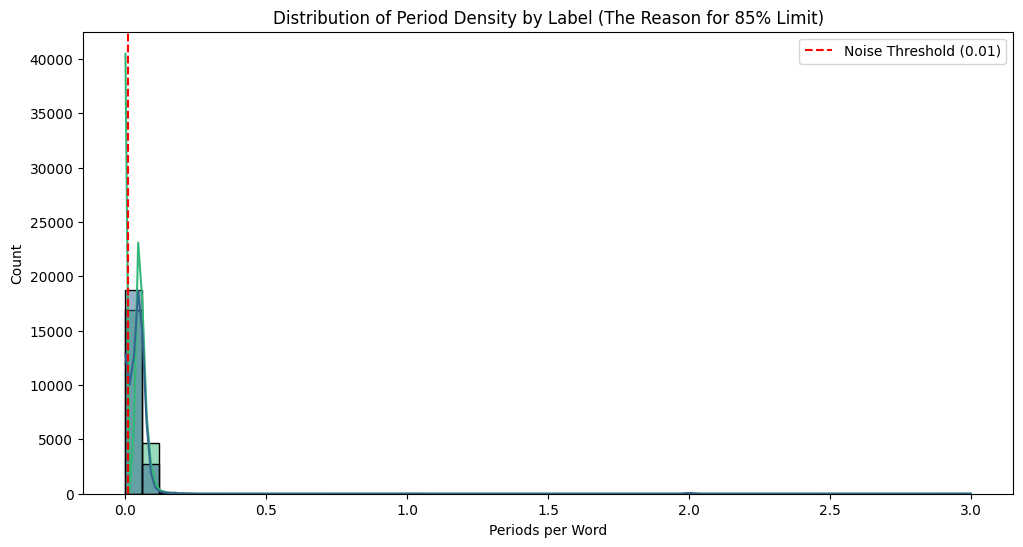

마침표가 거의 없는(0.01 미만) 노이즈 데이터 개수: 13933개
전체 데이터 중 노이즈 비율: 32.11%


In [3]:
# [Cell 2] 마침표 밀도 계산 및 분포 시각화

# 텍스트 내 마침표 개수를 단어 수로 나눈 'period_density' 파생 변수 생성
# (단어 1개당 마침표가 몇 개나 있는지 계산)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['period_count'] = df['text'].apply(lambda x: str(x).count('.'))
df['period_density'] = df['period_count'] / df['word_count']

# 시각화
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='period_density', hue='label', bins=50, kde=True, palette='viridis')
plt.title('Distribution of Period Density by Label (The Reason for 85% Limit)')
plt.xlabel('Periods per Word')
plt.axvline(x=0.01, color='red', linestyle='--', label='Noise Threshold (0.01)') # 임계값 표시
plt.legend()
plt.show()

# 노이즈 데이터 비율 계산
noise_count = len(df[df['period_density'] < 0.01])
print(f"마침표가 거의 없는(0.01 미만) 노이즈 데이터 개수: {noise_count}개")
print(f"전체 데이터 중 노이즈 비율: {noise_count / len(df) * 100:.2f}%")

In [4]:
# [Cell 3] 노이즈 데이터 제거 (전처리)

# 마침표 밀도가 0.01 이상인 데이터만 남김 (즉, 정상적인 문장 구조를 가진 데이터)
df_clean = df[df['period_density'] >= 0.01].copy()

print(f"정제 전 데이터 개수: {len(df)}")
print(f"정제 후 데이터 개수: {len(df_clean)}")
print(f"제거된 데이터 개수: {len(df) - len(df_clean)}")

# 정제된 데이터의 라벨 분포 확인
print("\n정제 후 라벨 분포:")
print(df_clean['label'].value_counts(normalize=True))

정제 전 데이터 개수: 43398
정제 후 데이터 개수: 29465
제거된 데이터 개수: 13933

정제 후 라벨 분포:
label
1.0    0.500424
0.0    0.499576
Name: proportion, dtype: float64


In [5]:
# [Cell 4] 정제된 데이터로 모델 학습 및 평가
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. 데이터 준비 (NaN 값 처리 포함)
X = df_clean['text'].fillna('')
y = df_clean['label']

# 2. 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 텍스트 벡터화 (TF-IDF)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# 4. 모델 학습 (로지스틱 회귀)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# 5. 예측 및 평가
y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)

print(f"============ 결과 ============")
print(f"정제된 데이터 학습 정확도: {accuracy:.4f} ({accuracy*100:.2f}%)")
print("\n분류 보고서:")
print(classification_report(y_test, y_pred))

============ 결과 ============
정제된 데이터 학습 정확도: 0.9810 (98.10%)

분류 보고서:
              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98      2964
         1.0       0.97      0.99      0.98      2929

    accuracy                           0.98      5893
   macro avg       0.98      0.98      0.98      5893
weighted avg       0.98      0.98      0.98      5893

